# Evaluate the results of alignment (20 and 100 frames)

In [6]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import copy
from importlib import reload

from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime
import gc

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load unaligned data

In [8]:
suffix = '_100frames'

# load data
file_path = "../data/EMD/EDXdataset.emd"
edx_unaligned_20, haadf_20, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame= True)
edx_unaligned_100, haadf_100, xray_energies = load_EDX(file_path, first_frame=0, last_frame=100, sum_frames=True, haadf_last_frame= True)

# Create object
tile_20 = EM_EDX(haadf_20, edx_unaligned_20, xray_energies)
tile_20.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_20.apply("binning", parameters={"dim": (2048, 2048, 250)})

# 100 frames
tile_100 = EM_EDX(haadf_100, edx_unaligned_100, xray_energies)
tile_100.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_100.apply("binning", parameters={"dim": (2048, 2048, 250)})

del edx_unaligned_100, edx_unaligned_20
gc.collect()

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


26796

### Load aligned data

In [29]:
# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile_20_aligned = pickle.load(file)
tile_20_aligned.summary()

# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20260114_062341_tile_aligned_100frames_align2zero.pkl', 'rb') as file:
    tile_100_aligned = pickle.load(file)
tile_100_aligned.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_path=tmp/unaligned_hsi_100frames, al...","(2048, 2048)","(2048, 2048, 250)",None


### Optional: bin and add mean filter

In [47]:
tile_20.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_20.apply("MeanFilterEDX", parameters={"kernel_size": 3})

tile_20_aligned.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_20_aligned.apply("MeanFilterEDX", parameters={"kernel_size": 3})


tile_100.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_100.apply("MeanFilterEDX", parameters={"kernel_size": 3})


tile_100_aligned.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_100_aligned.apply("MeanFilterEDX", parameters={"kernel_size": 3})



<EM_EDX | 5 steps logged>

### Visualize

Text(0.5, 1.0, 'Aligned 100 frames')

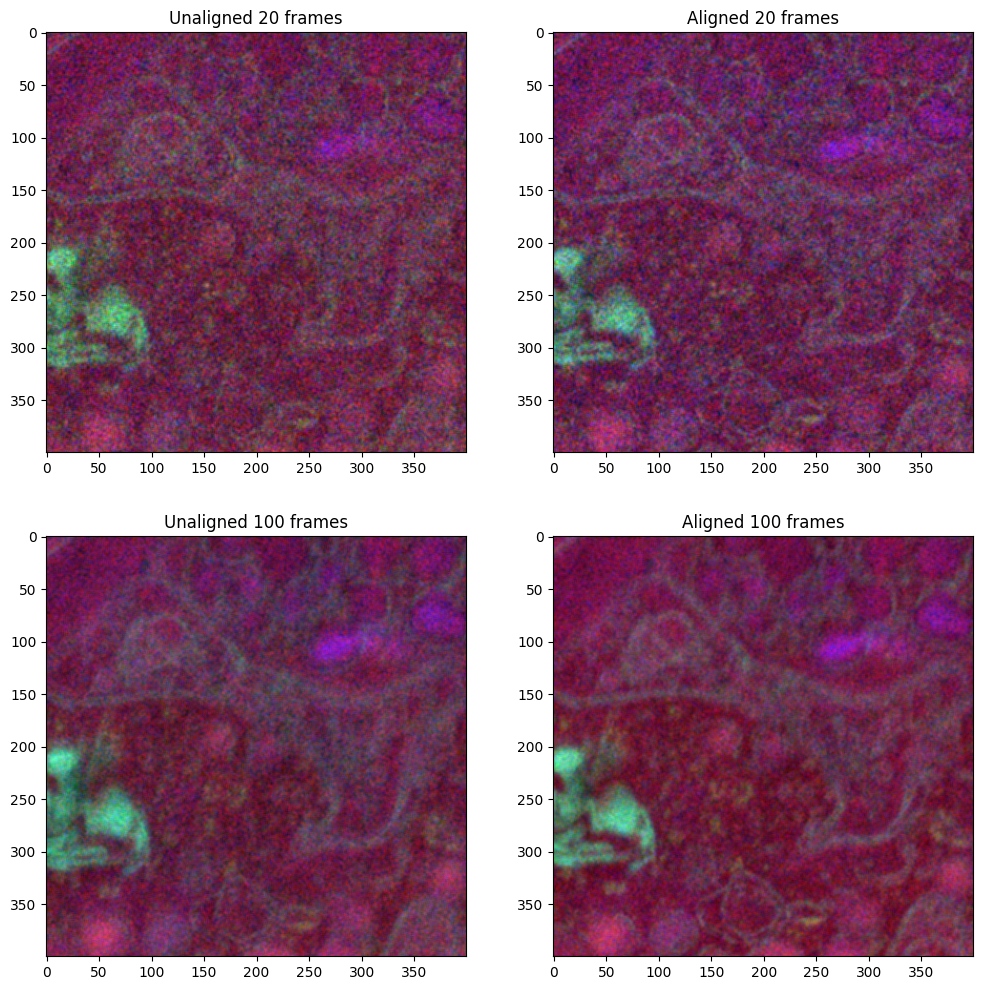

In [52]:
bands = [4,25,28]
#bands = [25,25,25]
#bands = [24,24,24]
f, ax = plt.subplots(2,2,figsize=(12,12))


#x1,x2,y1,y2 = [750,1000,250,750]
#x1,x2,y1,y2 = [600,1000,400,800]
x1,x2,y1,y2 = [0,1024,0,1024]
#x1,x2,y1,y2 = [0,2048,0,2048]
#x1,x2,y1,y2 = [1024,2048,0,1024]
#x1,x2,y1,y2 = [1250,2048,1250,2048]



x1,x2,y1,y2 = [200,600,250,650]

ax[0][0].imshow(tile_20.FalseColor(bands)[x1:x2,y1:y2,:])
ax[0][1].imshow(tile_20_aligned.FalseColor(bands)[x1:x2,y1:y2,:])

ax[1][0].imshow(tile_100.FalseColor(bands)[x1:x2,y1:y2,:])
ax[1][1].imshow(tile_100_aligned.FalseColor(bands)[x1:x2,y1:y2,:])

ax[0][0].set_title('Unaligned 20 frames')
ax[0][1].set_title('Aligned 20 frames')
ax[1][0].set_title('Unaligned 100 frames')
ax[1][1].set_title('Aligned 100 frames')

#for i in range(2):
#    for j in range(2):
#        ax[i][j].axis('off')